### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train and evaluating (precision, recall, f1) the Logistic Regression model using the Gradient Descent approach **to classify 0 and 1 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [191]:
import gzip 
import idx2numpy
import numpy as np 
from tqdm import tqdm
from sklearn.metrics import classification_report

In [192]:
class CFG : 
    def __init__(self):
        self.train_img_dir = 'data/train-images-idx3-ubyte.gz'
        self.train_label_dir =  'data/train-labels-idx1-ubyte.gz'
        self.test_img_dir = 'data/t10k-images-idx3-ubyte.gz'
        self.test_label_dir = 'data/t10k-labels-idx1-ubyte.gz'

In [193]:
def convert_idx_to_numpy(file_path) : 
    with gzip.open(file_path, 'rb') as f :
        data = idx2numpy.convert_from_file(f)
    
    if data is not None : 
        print(f"SHAPE OF DATA : {data.shape}")
    
    return data


In [194]:
config = CFG()

In [195]:
# read train data
print("TRAINING SET")
train_img = convert_idx_to_numpy(config.train_img_dir)
train_label = convert_idx_to_numpy(config.train_label_dir)

# read test data
print("TEST SET")
test_img = convert_idx_to_numpy(config.test_img_dir)
test_label = convert_idx_to_numpy(config.test_label_dir)

TRAINING SET
SHAPE OF DATA : (60000, 28, 28)
SHAPE OF DATA : (60000,)
TEST SET
SHAPE OF DATA : (10000, 28, 28)
SHAPE OF DATA : (10000,)


In [196]:
# normalize data 
train_img = train_img / 255.0
test_img = test_img / 255.0

In [197]:
# reshaping train data 
train_img = train_img.reshape(train_img.shape[0], -1)
train_label = train_label.reshape(-1, 1)

# reshaping test data
test_img = test_img.reshape(test_img.shape[0], -1)
test_label = test_label.reshape(-1, 1)

In [198]:
class LogisticRegression : 
    def __init__(self, lr=1e-4, epochs=100):
        self.lr = lr 
        self.epochs = epochs 
        self.W = None 
        self.b = 0 
    def softmax(self, z): 
        return np.exp(z) / np.sum(np.exp(z), axis=0)
    
    def sigmoid(self, z) :
        return 1 / (1 + np.exp(-z))
    
    def forward(self, X): 
        if self.W is None:
            return None
        z = X @ self.W.T + self.b 
        return self.sigmoid(z)
    
    def cross_entropy_loss(self, y, y_pred) : 
        return -np.mean(y * np.log(y_pred + 1e-9) + (1 - y) * np.log(1 - y_pred + 1e-9))

    def fit(self, X, y):
        nrows, ncols = X.shape

        self.W = np.zeros((1, ncols))
        self.b = 0 

        training_bar = tqdm(range(self.epochs), desc="TRAINING")
        for epoch in training_bar : 
            y_pred = self.forward(X)

            err = y_pred - y 
            dw = (1 / nrows) * np.dot(X.T, err)
            db = (1 / nrows) * np.sum(err)

            self.W -= self.lr * dw.T
            self.b -= self.lr * db 
            
            loss = self.cross_entropy_loss(y, y_pred)
            training_bar.set_postfix(loss=loss)

    def predict(self, X):
        y_pred = self.forward(X) 
        return [1 if p > 0.5 else 0 for p in y_pred]


In [199]:
def filter_data(X, y, criterion) : 
    filted_data_index = np.where(y == criterion)[0] 
    return X[filted_data_index], y[filted_data_index]

In [200]:
TRAIN_DIGIT_0_IMG, TRAIN_DIGIT_0_LABEL = filter_data(train_img, train_label, 0)
TRAIN_DIGIT_1_IMG, TRAIN_DIGIT_1_LABEL = filter_data(train_img, train_label, 1)

TEST_DIGIT_0_IMG, TEST_DIGIT_0_LABEL = filter_data(test_img, test_label, 0)
TEST_DIGIT_1_IMG, TEST_DIGIT_1_LABEL = filter_data(test_img, test_label, 1)

In [201]:
TRAIN_DIGIT_0_1_IMG = np.vstack([TRAIN_DIGIT_0_IMG, TRAIN_DIGIT_1_IMG])
TRAIN_DIGIT_0_1_LABEL = np.vstack([TRAIN_DIGIT_0_LABEL, TRAIN_DIGIT_1_LABEL])

TEST_DIGIT_0_1_IMG = np.vstack([TEST_DIGIT_0_IMG, TEST_DIGIT_1_IMG])
TEST_DIGIT_0_1_LABEL = np.vstack([TEST_DIGIT_0_LABEL, TEST_DIGIT_1_LABEL])

In [ ]:
lg = LogisticRegression() 
lg.fit(TRAIN_DIGIT_0_1_IMG, TRAIN_DIGIT_0_1_LABEL)

TRAINING: 100%|██████████| 100/100 [00:01<00:00, 97.85it/s, loss=0.662]


In [204]:
y_pred = lg.predict(TEST_DIGIT_0_1_IMG)

In [206]:
print(classification_report(TEST_DIGIT_0_1_LABEL, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      0.99      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



### Assignment 2 (4 scores):

- Use Numpy only to construct the Softmax Regression model.
- Train and evaluating (precision, recall, f1) the Softmax Regression model using the Gradient Descent approach **to classify 10 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [242]:
def one_hot(y) : 
    categories = np.unique(y)
    one_hot_mat = np.full((y.shape[0], len(categories)), 0)
    print("ONE HOT ENCODING MAP SHAPE : ", one_hot_mat.shape)
    for row, label in zip(one_hot_mat, y) : 
        row[label] = 1
    return one_hot_mat


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class SoftmaxRegression:
    def __init__(self, lr=1e-3, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.W = None
        self.b = None
        self.loss_history = []  

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        z = X @ self.W.T + self.b
        return self.softmax(z)

    def cross_entropy_loss(self, y_true, y_pred):
        return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

    def fit(self, X, y_one_hot):
        n_samples, n_features = X.shape
        n_classes = y_one_hot.shape[1]

        self.W = np.random.randn(n_classes, n_features) * 0.01
        self.b = np.zeros((1, n_classes))

        self.loss_history = []   

        bar = tqdm(range(self.epochs), desc="TRAINING")

        for _ in bar:
            y_pred = self.forward(X)

            err = y_pred - y_one_hot
            dW = (err.T @ X) / n_samples
            db = np.sum(err, axis=0, keepdims=True) / n_samples

            self.W -= self.lr * dW
            self.b -= self.lr * db

            loss = self.cross_entropy_loss(y_one_hot, y_pred)
            self.loss_history.append(loss) 

            bar.set_postfix(loss=loss)

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def plot_learning_curve(self):
        plt.figure()
        plt.plot(self.loss_history)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.grid()
        plt.show()

In [245]:
train_label_one_hot = one_hot(train_label).astype(int)

ONE HOT ENCODING MAP SHAPE :  (60000, 10)


TRAINING: 100%|██████████| 500/500 [01:04<00:00,  7.79it/s, loss=0.802]


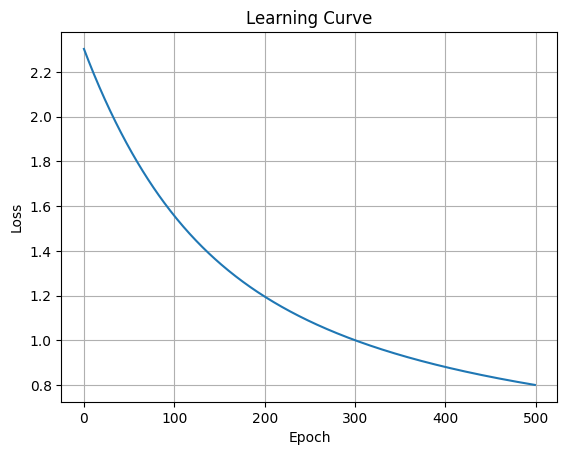

In [250]:
model = SoftmaxRegression(lr=1e-2, epochs=500)
model.fit(train_img, train_label_one_hot)

model.plot_learning_curve()

In [251]:
y_pred = model.predict(test_img)
print(classification_report(test_label, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       980
           1       0.86      0.96      0.91      1135
           2       0.88      0.80      0.84      1032
           3       0.78      0.87      0.82      1010
           4       0.85      0.86      0.86       982
           5       0.89      0.62      0.73       892
           6       0.86      0.91      0.89       958
           7       0.88      0.86      0.87      1028
           8       0.80      0.80      0.80       974
           9       0.81      0.82      0.81      1009

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.

In [252]:
from sklearn.linear_model import LogisticRegression as SK_LG

In [257]:
sk_logistic = SK_LG()
sk_logistic.fit(TRAIN_DIGIT_0_1_IMG, TRAIN_DIGIT_0_1_LABEL.ravel())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [258]:
y_pred = sk_logistic.predict(TEST_DIGIT_0_1_IMG)
print(classification_report(TEST_DIGIT_0_1_LABEL, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115

